# Task 4 - Continuous Unicycle Model (v, omega)

## Upgrade your motion model to continuous velocity-based control.

* The robot accepts control inputs as linear velocity (v) and angular velocity (omega) over a specified duration.
* Implement numerical integration (Forward Euler) using a small time step (dt) to compute updated (x, y, theta) coordinates.
* Print the state before and after each velocity command block.
* Plot the resulting continuous curved trajectory using Matplotlib.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = 0.0
y = 0.0
angle = 0.0
dt = 0.01

x_history = [x]
y_history = [y]
u_history = [np.cos(np.radians(angle))]
v_history = [np.sin(np.radians(angle))]

Enter commands: 
Press Enter on an empty line to finish and display the plot.

Initial Pos: (0.00, 0.00, 0.0°) | Executing: 1.0 0.5 3.0 | Final Pos: (2.00, 1.85, 85.9°)
Initial Pos: (2.00, 1.85, 85.9°) | Executing: 1.5 0.0 2.0 | Final Pos: (2.21, 4.85, 85.9°)
Initial Pos: (2.21, 4.85, 85.9°) | Executing: 1.2 -0.8 4.0 | Final Pos: (5.20, 4.56, -97.4°)
Initial Pos: (5.20, 4.56, -97.4°) | Executing: 0.8 0.0 2.5 | Final Pos: (4.94, 2.58, -97.4°)
Initial Pos: (4.94, 2.58, -97.4°) | Executing: 1.0 1.2 2.5 | Final Pos: (6.57, 2.24, 74.5°)
Initial Pos: (6.57, 2.24, 74.5°) | Executing: 0.5 -1.5 1.5 | Final Pos: (7.16, 2.34, -54.4°)
Initial Pos: (7.16, 2.34, -54.4°) | Executing: 1.8 0.2 3.5 | Final Pos: (12.25, -1.15, -14.3°)
Initial Pos: (12.25, -1.15, -14.3°) | Executing: 0.4 -0.6 2.0 | Final Pos: (12.75, -1.71, -83.1°)


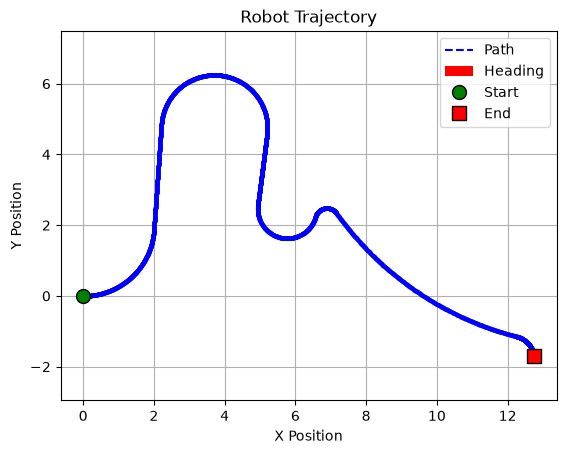

In [2]:
print("Enter commands: ")
print("Press Enter on an empty line to finish and display the plot.\n")

while True:
    user_input = input().strip()
    if not user_input:
        break

    parts = user_input.split()
    if len(parts) != 3:
        print("Invalid command")
        continue

    try:
        v_val = float(parts[0])
        w_val = float(parts[1])
        t_val = float(parts[2])
    except ValueError:
        print("Invalid command")
        continue

    initial_pos = f"({x:.2f}, {y:.2f}, {angle:.1f}°)"

    steps = int(t_val / dt)
    for i in range(steps):
        rad = np.radians(angle)
        x = x + v_val * np.cos(rad) * dt
        y = y + v_val * np.sin(rad) * dt
        angle = angle + np.degrees(w_val * dt)

        rad = np.radians(angle)
        x_history.append(x)
        y_history.append(y)
        u_history.append(np.cos(rad))
        v_history.append(np.sin(rad))

    final_pos = f"({x:.2f}, {y:.2f}, {angle:.1f}°)"
    print(f"Initial Pos: {initial_pos} | Executing: {user_input} | Final Pos: {final_pos}")

plt.figure()
plt.plot(x_history, y_history, "b--", label="Path")
plt.plot(x_history, y_history, "bo", markersize=2)
plt.quiver(x_history,y_history,u_history,v_history,color="red",label="Heading",angles="xy",)
plt.plot(x_history[0],y_history[0],"go",markersize=10,markeredgecolor="black",label="Start",)
plt.plot(x_history[-1],y_history[-1],"rs",markersize=10,markeredgecolor="black",label="End",)
plt.gca().set_aspect("equal", adjustable="datalim")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Robot Trajectory")
plt.grid(True)
plt.legend()
plt.show()